# Municipal Water Use and Population Growth over time

## Setup and Data Cleaning

In [4]:
#check directory
getwd()

# Load libraries
library(tidyr) #data organization
library(ggplot2) #data visualization
library(dplyr) #data cleaning
library(GGally) #statistics
library(janitor) #data cleaning
library(lubridate) #dates
library(stringr) #strings
library(naniar) #missingness

#more data viz libraries
library(ggrepel)      # for smart label placement
library(scales)       # for nice axis formatting
library(sf)           # for maps 

# Set a clean theme as default
theme_set(theme_minimal(base_size = 14))

[1] "/home/user/EDScapstone/scripts"


Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union





Attaching package: ‘janitor’




The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test





Attaching package: ‘lubridate’




The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




Linking to GEOS 3.12.1, GDAL 3.8.4, PROJ 9.4.0; sf_use_s2() is TRUE



In [5]:
#navigate to raw_data

setwd("/home/user/EDScapstone/raw_data")
my_wd <- getwd()

#see files in directory
raw_files <- list.files(my_wd)

raw_files

[1] "cb_2018_us_state_20m"                      
 [2] "cb_2018_us_ua10_500k"                      
 [3] "Cities shapefile"                          
 [4] "Cities shapefile.zip"                      
 [5] "City-characteristics.csv"                  
 [6] "Municipal_water_uses_dataset_2005-2017.csv"
 [7] "old"                                       
 [8] "readme.md"                                 
 [9] "tl_2020_us_uac20"                          
[10] "tl_2020_us_uac20.zip"

In [6]:
#create dataframe for Municipal_Water_Uses
Municipal_Water_Uses<-read.csv("Municipal_water_uses_dataset_2005-2017.csv")

glimpse(Municipal_Water_Uses)

n_distinct(Municipal_Water_Uses$city)

#data names are not all in the same format 
#date is shown as string, not date format
#should also separate city and state in dataset

Rows: 16,305
Columns: 8
$ USCensusID            <chr> "1600000US4801000", "1600000US4801000", "1600000…
$ city                  <chr> "Abilene, Texas", "Abilene, Texas", "Abilene, Te…
$ date                  <chr> "1/1/2005", "2/1/2005", "3/1/2005", "4/1/2005", …
$ population            <dbl> 120267, 120267, 120267, 120267, 120267, 120267, …
$ res_billed_gallons    <dbl> 193610000, 168050000, 158100000, 190420000, 2601…
$ cii_billed_gallons    <dbl> 202640000, 198560000, 161420000, 191640000, 2106…
$ master_billed_gallons <dbl> 64870000, 51900000, 47580000, 68730000, 68170000…
$ total_billed_gallons  <dbl> 461120000, 418510000, 367100000, 450790000, 5389…


[1] 126

In [7]:
#Rename to snake case
Municipal_Water_Uses_clean<-clean_names(Municipal_Water_Uses,"snake")

head(Municipal_Water_Uses_clean)

,us_census_id,city,date,population,res_billed_gallons,cii_billed_gallons,master_billed_gallons,total_billed_gallons
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1600000US4801000,"Abilene, Texas",1/1/2005,120267,193610000,202640000,64870000,461120000
2,1600000US4801000,"Abilene, Texas",2/1/2005,120267,168050000,198560000,51900000,418510000
3,1600000US4801000,"Abilene, Texas",3/1/2005,120267,158100000,161420000,47580000,367100000
4,1600000US4801000,"Abilene, Texas",4/1/2005,120267,190420000,191640000,68730000,450790000
5,1600000US4801000,"Abilene, Texas",5/1/2005,120267,260170000,210640000,68170000,538980000
6,1600000US4801000,"Abilene, Texas",6/1/2005,120267,283130000,227100000,102870000,613100000


In [8]:
# Convert date to date format from string

Municipal_Water_Uses_clean <- Municipal_Water_Uses_clean %>%
    mutate(
    date = as.Date(date, format="%m/%d/%Y"))

# add year and state from existing date and city columns 

Municipal_Water_Uses_clean<- Municipal_Water_Uses_clean%>%
    mutate(
    year = year(date),                             # Extract year as separate column
    state = str_extract(city, "(?<=, ).*")        # Extract state as separate column
    )

n_distinct(Municipal_Water_Uses$city)

head(Municipal_Water_Uses_clean)

# data types look correct, variables show as numeric, indicating NA values are treated correctly

# units? add columns for billions of gallons to be aggregated to thousands, acre-feet for interpretation? should that be done last for visualization? 

[1] 126

,us_census_id,city,date,population,res_billed_gallons,cii_billed_gallons,master_billed_gallons,total_billed_gallons,year,state
,<chr>,<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,1600000US4801000,"Abilene, Texas",2005-01-01,120267,193610000,202640000,64870000,461120000,2005,Texas
2,1600000US4801000,"Abilene, Texas",2005-02-01,120267,168050000,198560000,51900000,418510000,2005,Texas
3,1600000US4801000,"Abilene, Texas",2005-03-01,120267,158100000,161420000,47580000,367100000,2005,Texas
4,1600000US4801000,"Abilene, Texas",2005-04-01,120267,190420000,191640000,68730000,450790000,2005,Texas
5,1600000US4801000,"Abilene, Texas",2005-05-01,120267,260170000,210640000,68170000,538980000,2005,Texas
6,1600000US4801000,"Abilene, Texas",2005-06-01,120267,283130000,227100000,102870000,613100000,2005,Texas


In [9]:
# population looks like the same value for each month. I am interested in how water use changes annually. So one instance per year should be enough
# get end-of-year poplation by extracting December population 

Municipal_Water_Uses_clean <- Municipal_Water_Uses_clean %>%
    mutate(
        month_index = as.integer(format(date, "%m")
    )) 

Municipal_Water_Uses_clean <- Municipal_Water_Uses_clean %>%
    mutate(
        pop_eoy = ifelse(
            month_index == 12,   #if month is December
            population,         # show population
            NA                   # otherwise end of year population is NA
        )
    )

n_distinct(Municipal_Water_Uses$city)

filtered_df <- Municipal_Water_Uses_clean %>%       #filtering works on numbers, not text
    filter(
        us_census_id == "1600000US0477000"
    )

head(filtered_df, 20)

[1] 126

,us_census_id,city,date,population,res_billed_gallons,cii_billed_gallons,master_billed_gallons,total_billed_gallons,year,state,month_index,pop_eoy
,<chr>,<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<dbl>
1,1600000US0477000,"Tucson, Arizona",2005-01-01,644414,1826147363,567247461,NA,2393394824,2005,Arizona,1,NA
2,1600000US0477000,"Tucson, Arizona",2005-02-01,644414,1675629956,572126500,NA,2247756456,2005,Arizona,2,NA
3,1600000US0477000,"Tucson, Arizona",2005-03-01,644414,1793311898,729594862,NA,2522906760,2005,Arizona,3,NA
4,1600000US0477000,"Tucson, Arizona",2005-04-01,644414,2048443688,646051430,NA,2694495118,2005,Arizona,4,NA
5,1600000US0477000,"Tucson, Arizona",2005-05-01,644414,2368145500,986723362,NA,3354868862,2005,Arizona,5,NA
6,1600000US0477000,"Tucson, Arizona",2005-06-01,644414,2835663093,1209856834,NA,4045519927,2005,Arizona,6,NA
7,1600000US0477000,"Tucson, Arizona",2005-07-01,644414,3212208447,1384783979,NA,4596992426,2005,Arizona,7,NA
8,1600000US0477000,"Tucson, Arizona",2005-08-01,644414,2681391115,1140259967,NA,3821651082,2005,Arizona,8,NA
9,1600000US0477000,"Tucson, Arizona",2005-09-01,644414,2529804307,996485959,NA,3526290266,2005,Arizona,9,NA


### Investigate Missingness in Municipal Water Use Dataset


In [10]:
#Get 5-number stats on Muncipal water use dataset
summary(Municipal_Water_Uses_clean)

# get unique cities
n_distinct(Municipal_Water_Uses_clean$city)

filtered_df2 <- Municipal_Water_Uses_clean %>%
    filter( us_census_id == "1600000US0477000"
    )



#no missing cities, dates, or total_billed_gallons which is good. Missing values in res_billed_gallons and cii_billed_gallons could be true values. Not sure why there are so many more missing values in master_billed_gallons than the other two or what that column is for.



 us_census_id           city                date              population     
 Length:16305       Length:16305       Min.   :2005-01-01   Min.   :   2718  
 Class :character   Class :character   1st Qu.:2008-12-01   1st Qu.:  38617  
 Mode  :character   Mode  :character   Median :2012-03-01   Median : 110990  
                                       Mean   :2011-12-18   Mean   : 353600  
                                       3rd Qu.:2015-02-01   3rd Qu.: 340269  
                                       Max.   :2017-12-01   Max.   :8622698  
                                                                             
 res_billed_gallons  cii_billed_gallons  master_billed_gallons
 Min.   :3.915e+06   Min.   :2.323e+06   Min.   :7.480e+02    
 1st Qu.:8.974e+07   1st Qu.:7.108e+07   1st Qu.:1.401e+07    
 Median :2.663e+08   Median :2.025e+08   Median :7.280e+07    
 Mean   :6.647e+08   Mean   :4.997e+08   Mean   :1.212e+08    
 3rd Qu.:8.364e+08   3rd Qu.:5.037e+08   3rd Qu.:1.519e+08   

[1] 126

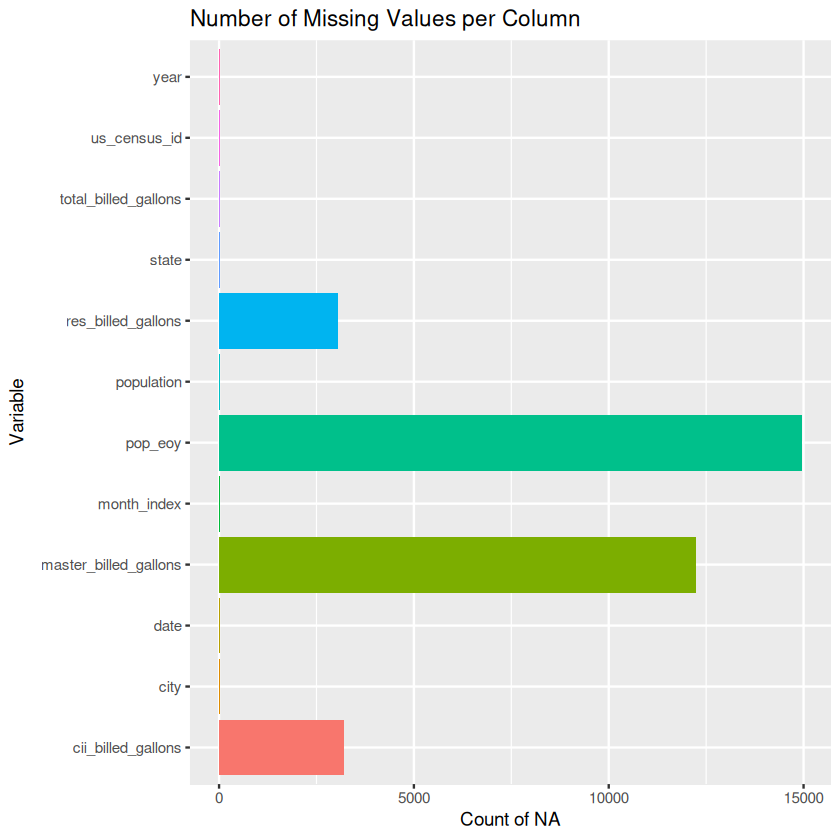

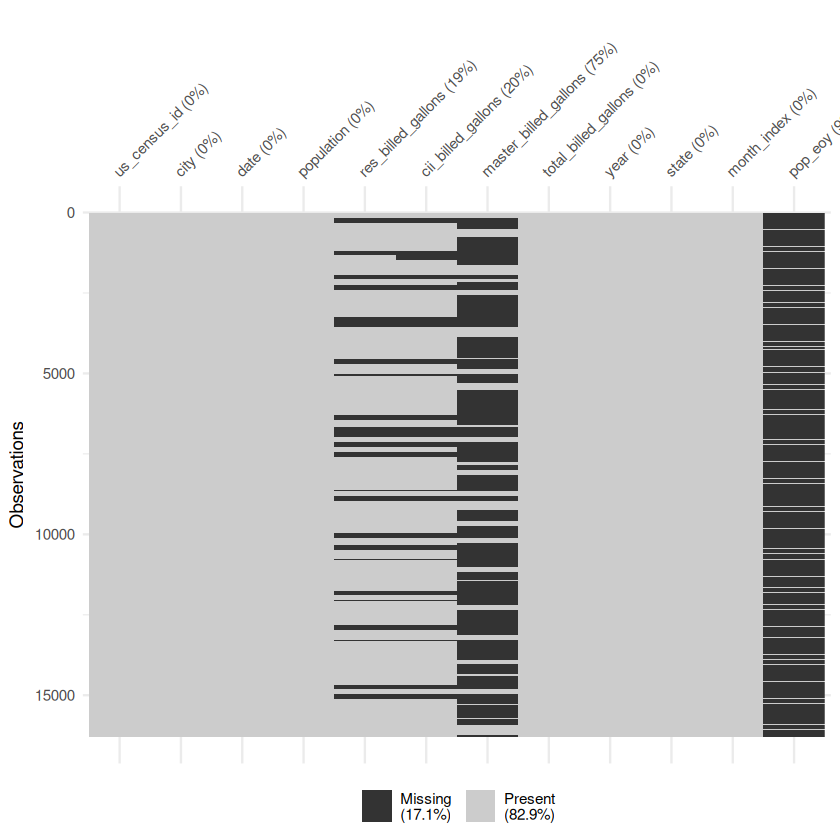

In [10]:
#plot NA values to understand them better

Municipal_Water_Uses_clean_NA <- Municipal_Water_Uses_clean %>%
  summarise(across(everything(), ~ sum(is.na(.)))) %>%
  pivot_longer(cols = everything(), names_to = "variable", values_to = "NA_values")

# Plot NA counts
ggplot(Municipal_Water_Uses_clean_NA, aes(x = variable, y = NA_values, fill = variable)) +  #data
geom_col() +  #barchart
 theme(legend.position = "none") +
 coord_flip() + #flip axis
  labs(
    title = "Number of Missing Values per Column",
    x = "Variable",
    y = "Count of NA"
  )


# visualize missingness using vis_miss()
vis_miss(Municipal_Water_Uses_clean)

# res_billed and cii_billed have similar number of values, more likely to be connected than master_billed
# visualization shows all res_billed and cii_billed NAs also have a master_billed NA

# Missingness Exploration: total_billed_gallons is not missing any values. It is very possible that the more detailed data could not be obtained for all of the cities. In some cases there might be a difference in interpretation between the more well-known categories (res_billed and cii_billed) while master_billed seems to have more missing values.

# After consulting metadata it looks like total_billed_gallons = cii_billed_gallons + res_billed_gallons + master_billed_gallons. Master_billed_gallons is more like water that did not go to a specific sector. There could be differences in city reporting on master_billed_gallons and could be part of the res or cii if master_billed is zero.

In [11]:
#investigate: Check on if master_billed= res_billed + cii_billed or if there is genuinely missing data.


#select observations where res_bille + cii_billed = total_billed
Municipal_Water_Uses_clean_subset1 <- Municipal_Water_Uses_clean %>%       #subset 1 shows where  total_billed = res_billed + cii_billed, then master_billed is 0
filter(res_billed_gallons+cii_billed_gallons == total_billed_gallons)

glimpse(Municipal_Water_Uses_clean_subset1)

#about half of the NA observations in master_billed_gallons


Rows: 7,658
Columns: 12
$ us_census_id          <chr> "1600000US3501780", "1600000US3501780", "1600000…
$ city                  <chr> "Alamogordo, New Mexico", "Alamogordo, New Mexic…
$ date                  <date> 2005-01-01, 2005-04-01, 2005-05-01, 2005-10-01,…
$ population            <dbl> 35837, 35837, 35837, 35837, 35837, 35734, 35734,…
$ res_billed_gallons    <dbl> 67736681, 71648519, 101044919, 101156132, 772845…
$ cii_billed_gallons    <dbl> 15620110, 16423133, 18447064, 21888088, 17563571…
$ master_billed_gallons <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, …
$ total_billed_gallons  <dbl> 83356791, 88071652, 119491983, 123044220, 948480…
$ year                  <dbl> 2005, 2005, 2005, 2005, 2005, 2006, 2006, 2006, …
$ state                 <chr> "New Mexico", "New Mexico", "New Mexico", "New M…
$ month_index           <int> 1, 4, 5, 10, 11, 1, 2, 3, 4, 5, 8, 10, 11, 12, 2…
$ pop_eoy               <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, …


if res\_billed\_gallons, cii\_billed\_gallons = total\_billed\_gallons, should master\_billed\_gallons equal 0? Is it enough that it's NA?  



### Final dataset from missingness evaluation

In [12]:

obs_count <- colSums(!is.na(Municipal_Water_Uses_clean))

print(obs_count)


#filter out NA
#Municipal_Water_Uses_clean_removeNA <- Municipal_Water_Uses_clean%>%
#    filter(if_all(c(res_billed_gallons, cii_billed_gallons, master_billed_gallons), ~ !is.na(.) )    
#   )

#summary(Municipal_Water_Uses_clean_No_NA)

# I THINK THIS IS WHERE THE CITIES GOT DROPPED-- leaving it out for now and using na.rm = TRUE for analysis

# removed NA data from specific columns. For time series purposes this could mean that there are incomplete series. Is it better to take the row out completely? there will be gaps




         us_census_id                  city                  date 
                16305                 16305                 16305 
           population    res_billed_gallons    cii_billed_gallons 
                16305                 13258                 13114 
master_billed_gallons  total_billed_gallons                  year 
                 4090                 16305                 16305 
                state           month_index               pop_eoy 
                16305                 16305                  1352 


Is the goal to remove NAs from the dataset? Or just account for them - !s.na - in each function?

## Plotting data

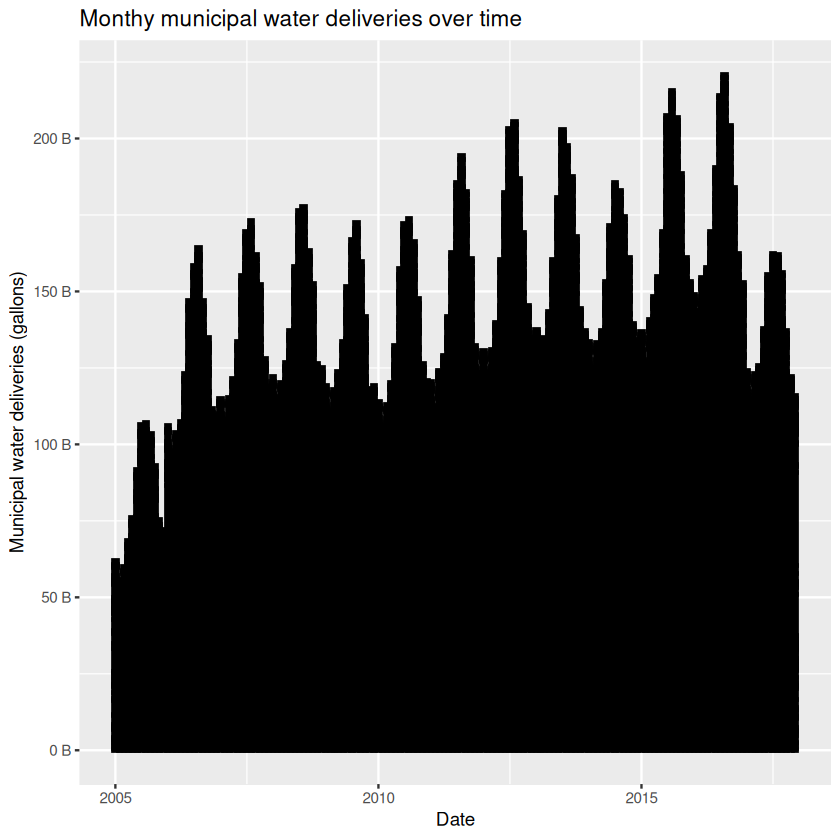

In [13]:
# Quick plot of original data by month
original_data_plot <- ggplot(Municipal_Water_Uses_clean, aes(x = date, y = total_billed_gallons)) +
  geom_col(linewidth = 1.0, color = "black") +
  scale_y_continuous(labels = unit_format(unit = "B", scale = 1e-9)) +
  labs(
    title = "Monthy municipal water deliveries over time",
    x = "Date",
    y = "Municipal water deliveries (gallons)"
  )

original_data_plot


In [14]:
#summarize for easier interpretation

#summarize res, cii, total water use by year
Municipal_Water_Uses_clean_summary_year<-Municipal_Water_Uses_clean%>%
    group_by(year)%>%
    summarise(res_billed_gallons_summarise = sum(res_billed_gallons),
             cii_billed_gallons_summarise = sum(cii_billed_gallons),
             master_billed_gallons_summarise = sum(master_billed_gallons),
             total_billed_gallons_summarise = sum(total_billed_gallons)             
             )

head(Municipal_Water_Uses_clean_summary_year)




year,res_billed_gallons_summarise,cii_billed_gallons_summarise,master_billed_gallons_summarise,total_billed_gallons_summarise
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2005,NA,NA,NA,9.726543e+11
2006,NA,NA,NA,1.511883e+12
2007,NA,NA,NA,1.653339e+12
2008,NA,NA,NA,1.701973e+12
2009,NA,NA,NA,1.635189e+12
2010,NA,NA,NA,1.650539e+12


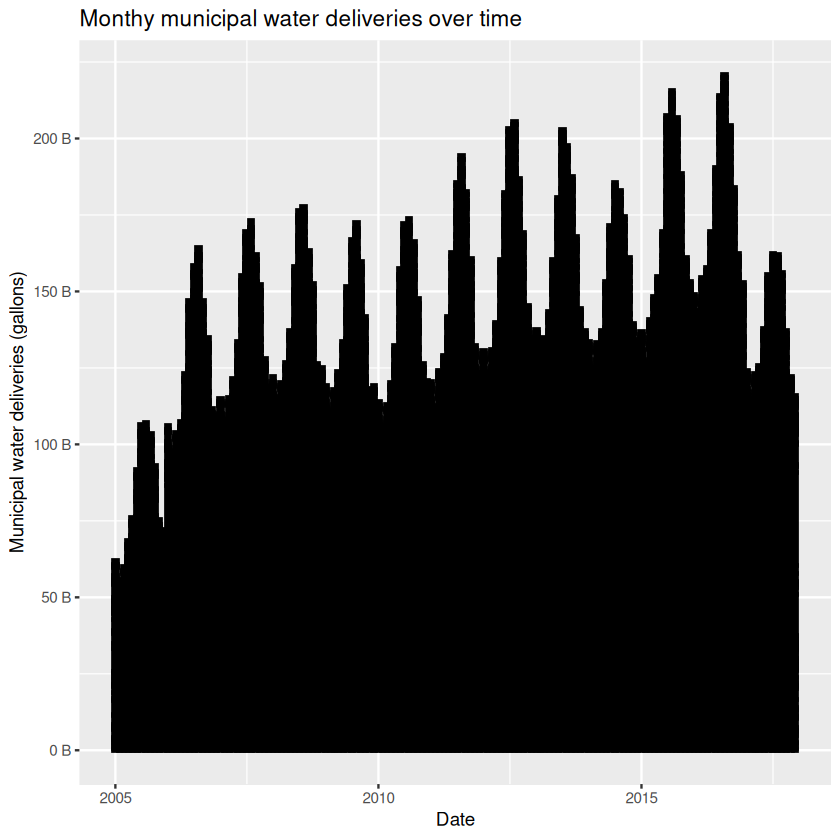

# A tibble: 52 × 3
    year water_use_category              billed_gallons
   <dbl> <chr>                                    <dbl>
 1  2005 res_billed_gallons_summarise          NA      
 2  2005 cii_billed_gallons_summarise          NA      
 3  2005 master_billed_gallons_summarise       NA      
 4  2005 total_billed_gallons_summarise         9.73e11
 5  2006 res_billed_gallons_summarise          NA      
 6  2006 cii_billed_gallons_summarise          NA      
 7  2006 master_billed_gallons_summarise       NA      
 8  2006 total_billed_gallons_summarise         1.51e12
 9  2007 res_billed_gallons_summarise          NA      
10  2007 cii_billed_gallons_summarise          NA      
# ℹ 42 more rows


Warning message:
“Removed 39 rows containing missing values or values outside the scale range
(`geom_line()`).”


Warning message:
“Removed 39 rows containing missing values or values outside the scale range
(`geom_point()`).”


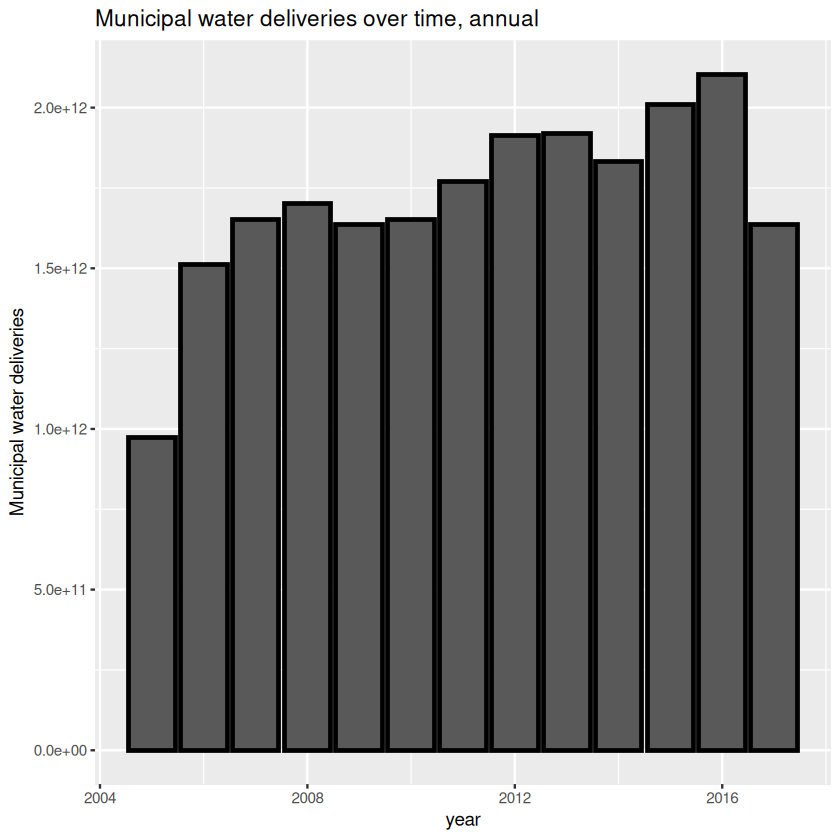

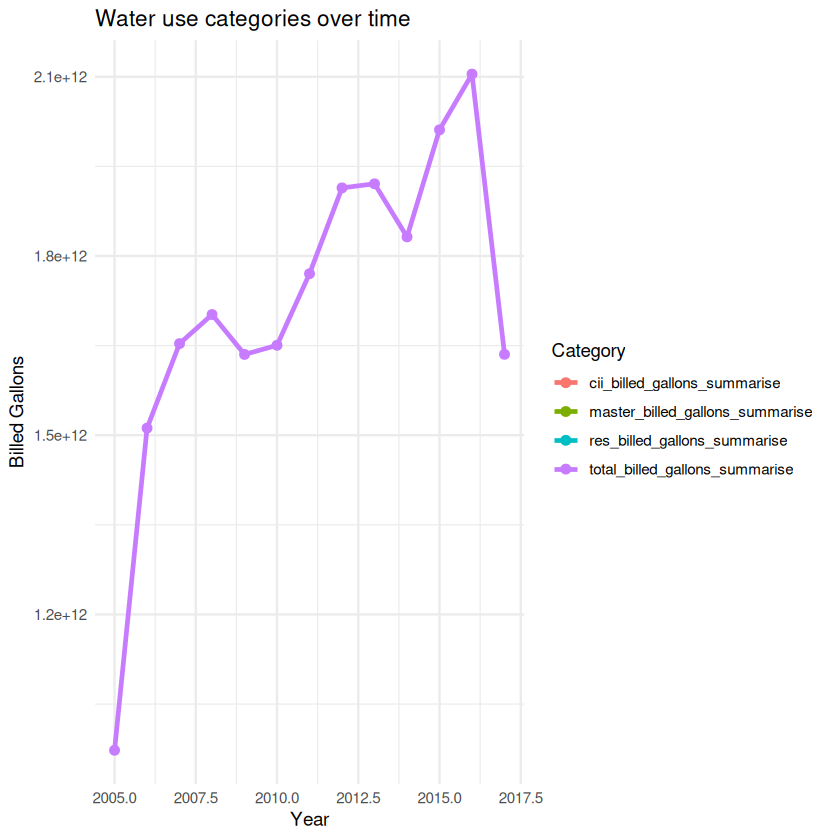

In [15]:
#Bring in raw data plot
original_data_plot

#Plot annual data

ggplot(Municipal_Water_Uses_clean_summary_year, aes(x = year, y = total_billed_gallons_summarise)) +
  geom_col(linewidth = 1.0, color = "black") +
  labs(
    title = "Municipal water deliveries over time, annual",
    x = "year",
    y = "Municipal water deliveries"
  )


#need to join city region from city_characteristics dataset to see it properly

# Plot total, res_, cii_., master_ on same plot

# Pivot longer to add all variables to one
Municipal_Water_Uses_clean_summary_year_long <- pivot_longer(
    Municipal_Water_Uses_clean_summary_year,
    cols = c(res_billed_gallons_summarise, cii_billed_gallons_summarise, master_billed_gallons_summarise, total_billed_gallons_summarise),
    names_to = "water_use_category",
    values_to = "billed_gallons"
)

print(Municipal_Water_Uses_clean_summary_year_long)

# Plot on line chart
ggplot(Municipal_Water_Uses_clean_summary_year_long, aes(x = year, y = billed_gallons, color = water_use_category)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  labs(
    title = "Water use categories over time",
    x = "Year",
    y = "Billed Gallons",
    color = "Category"
  ) +
  theme_minimal()


In [16]:

n_distinct(Municipal_Water_Uses_clean$city)

# create water use divided by population

[1] 126

## Population Size

In [17]:
### NCES City Sizes

In [11]:
# Need to normalize sums for better understanding of differences

# Can work with annual dataset now, summarize the important variables by year

#summarize res, cii, total water use, population, by us_census_id and year
Municipal_Water_Uses_clean_summary_CensusID_year<-Municipal_Water_Uses_clean%>%
    group_by(us_census_id, year)%>%
    summarise(res_billed_gallons_summarise = sum(res_billed_gallons, na.rm = TRUE),
             cii_billed_gallons_summarise = sum(cii_billed_gallons, na.rm = TRUE),
             master_billed_gallons_summarise = sum(master_billed_gallons,na.rm = TRUE),
             total_billed_gallons_summarise = sum(total_billed_gallons, na.rm = TRUE),
             population_summarise = sum(pop_eoy, na.rm = TRUE)
             )
head(Municipal_Water_Uses_clean_summary_CensusID_year)

# Total water use divided by population
Annual_Municipal_Water_Uses_clean <- Municipal_Water_Uses_clean_summary_CensusID_year %>%     #rename dataframe 
    mutate(
        res_per_capita_gallons = res_billed_gallons_summarise / population_summarise,
        total_per_capita_gallons = total_billed_gallons_summarise / population_summarise
    )

head(Annual_Municipal_Water_Uses_clean)

filtered_df <- Annual_Municipal_Water_Uses_clean %>%
    filter(us_census_id == "1600000US0455000"
 )

head(filtered_df)
# Residential water use divided by population

`summarise()` has grouped output by 'us_census_id'. You can override using the
`.groups` argument.


us_census_id,year,res_billed_gallons_summarise,cii_billed_gallons_summarise,master_billed_gallons_summarise,total_billed_gallons_summarise,population_summarise
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1600000US0423620,2011,1389406136,896840384,0,2396197544,66660
1600000US0423620,2012,1383120962,910578048,0,2401789389,67393
1600000US0423620,2013,1391960236,910909910,0,2414419868,68135
1600000US0423620,2014,1343336911,902933277,0,2361180084,68884
1600000US0423620,2015,1343336911,902933277,0,2361180084,70643
1600000US0423620,2016,1406167971,925033761,0,2429817759,71656


us_census_id,year,res_billed_gallons_summarise,cii_billed_gallons_summarise,master_billed_gallons_summarise,total_billed_gallons_summarise,population_summarise,res_per_capita_gallons,total_per_capita_gallons
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1600000US0423620,2011,1389406136,896840384,0,2396197544,66660,20843.18,35946.56
1600000US0423620,2012,1383120962,910578048,0,2401789389,67393,20523.21,35638.56
1600000US0423620,2013,1391960236,910909910,0,2414419868,68135,20429.45,35435.82
1600000US0423620,2014,1343336911,902933277,0,2361180084,68884,19501.44,34277.63
1600000US0423620,2015,1343336911,902933277,0,2361180084,70643,19015.85,33424.12
1600000US0423620,2016,1406167971,925033761,0,2429817759,71656,19623.87,33909.48


us_census_id,year,res_billed_gallons_summarise,cii_billed_gallons_summarise,master_billed_gallons_summarise,total_billed_gallons_summarise,population_summarise,res_per_capita_gallons,total_per_capita_gallons
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1600000US0455000,2007,0,0,0,100661678876,1454201,0.00,69221.30
1600000US0455000,2008,0,0,0,94457819236,1462547,0.00,64584.47
1600000US0455000,2009,0,0,0,92869381396,1462705,0.00,63491.53
1600000US0455000,2010,32028211072,3544859516,0,72324734936,1456934,21983.30,49641.74
1600000US0455000,2011,58307391232,20241618176,0,78554009408,1459609,39947.27,53818.53
1600000US0455000,2012,59425317776,30989352768,0,90414670544,1472201,40364.95,61414.62


In [12]:
#Check summary by city and year for suitable joining
head(Annual_Municipal_Water_Uses_clean)

us_census_id,year,res_billed_gallons_summarise,cii_billed_gallons_summarise,master_billed_gallons_summarise,total_billed_gallons_summarise,population_summarise,res_per_capita_gallons,total_per_capita_gallons
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1600000US0423620,2011,1389406136,896840384,0,2396197544,66660,20843.18,35946.56
1600000US0423620,2012,1383120962,910578048,0,2401789389,67393,20523.21,35638.56
1600000US0423620,2013,1391960236,910909910,0,2414419868,68135,20429.45,35435.82
1600000US0423620,2014,1343336911,902933277,0,2361180084,68884,19501.44,34277.63
1600000US0423620,2015,1343336911,902933277,0,2361180084,70643,19015.85,33424.12
1600000US0423620,2016,1406167971,925033761,0,2429817759,71656,19623.87,33909.48


In [13]:
#bring in city characteristics spreadsheet for joining
setwd("/home/user/EDScapstone/raw_data")
getwd()

#create dataframe for City Characteristics
City_Characteristics <-read.csv("City-characteristics.csv")

head(City_Characteristics)


[1] "/home/user/EDScapstone/raw_data"

,USCensusID,City,CII.RES,US_census_region,Climate_region,Avg_population,January.precipitation,February.precipitation,March.precipitation,April.precipitation,⋯,Percent.housing.units.built.between.1950.1989,Percent.housing.units.built.before.1950,Percent.housing.units.built.earlier.to.1990,Median.rooms,Percent.impervious.area,Area.open.NLCD,Area.low.development.NLCD,Area.medium.development.NLCD,Area.high.development.NLCD,Service.area.sq.meters
,<chr>,<chr>,<dbl>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1600000US4801000,"Abilene city, Texas",0.727,South,Temperate,123729,25.9,35.6,42.5,45.8,⋯,63.3,14.7,78.0,5.3,16.4,13874.8,10720.6,6208.8,3755.7,290335000
2,1600000US4500550,"Aiken city, South Carolina",NA,South,Temperate,29406,110.8,103.6,111.3,84.8,⋯,49.6,7.1,56.7,6.0,9.0,7626.2,6274.4,1805.4,573.7,194774000
3,1600000US3501780,"Alamogordo city, New Mexico",0.205,West,Arid,32986,17.7,12.9,9.5,8.9,⋯,69.3,4.5,73.8,5.4,14.4,1792.0,3050.2,965.0,208.4,56002000
4,1600000US3502000,"Albuquerque city, New Mexico",0.380,West,Arid,614980,10.8,11.8,14.6,17.3,⋯,57.6,7.2,64.8,5.3,26.9,11553.2,32002.9,24592.5,5344.4,489188000
5,1600000US4202184,"Altoona city, Pennsylvania",0.454,Northeast,Continental,54369,65.2,55.3,79.2,80.0,⋯,37.1,58.7,95.8,6.1,18.9,4855.7,6346.8,3384.4,1673.1,131990000
6,1600000US4803000,"Amarillo city, Texas",0.653,South,Arid,196728,17.0,15.3,30.3,32.7,⋯,62.3,14.9,77.2,5.1,25.2,7145.7,19825.2,7535.3,4717.4,266556000


In [14]:
#Rename to snake case
City_Characteristics_clean<-clean_names(City_Characteristics,"snake")

head(City_Characteristics_clean)

,us_census_id,city,cii_res,us_census_region,climate_region,avg_population,january_precipitation,february_precipitation,march_precipitation,april_precipitation,⋯,percent_housing_units_built_between_1950_1989,percent_housing_units_built_before_1950,percent_housing_units_built_earlier_to_1990,median_rooms,percent_impervious_area,area_open_nlcd,area_low_development_nlcd,area_medium_development_nlcd,area_high_development_nlcd,service_area_sq_meters
,<chr>,<chr>,<dbl>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1600000US4801000,"Abilene city, Texas",0.727,South,Temperate,123729,25.9,35.6,42.5,45.8,⋯,63.3,14.7,78.0,5.3,16.4,13874.8,10720.6,6208.8,3755.7,290335000
2,1600000US4500550,"Aiken city, South Carolina",NA,South,Temperate,29406,110.8,103.6,111.3,84.8,⋯,49.6,7.1,56.7,6.0,9.0,7626.2,6274.4,1805.4,573.7,194774000
3,1600000US3501780,"Alamogordo city, New Mexico",0.205,West,Arid,32986,17.7,12.9,9.5,8.9,⋯,69.3,4.5,73.8,5.4,14.4,1792.0,3050.2,965.0,208.4,56002000
4,1600000US3502000,"Albuquerque city, New Mexico",0.380,West,Arid,614980,10.8,11.8,14.6,17.3,⋯,57.6,7.2,64.8,5.3,26.9,11553.2,32002.9,24592.5,5344.4,489188000
5,1600000US4202184,"Altoona city, Pennsylvania",0.454,Northeast,Continental,54369,65.2,55.3,79.2,80.0,⋯,37.1,58.7,95.8,6.1,18.9,4855.7,6346.8,3384.4,1673.1,131990000
6,1600000US4803000,"Amarillo city, Texas",0.653,South,Arid,196728,17.0,15.3,30.3,32.7,⋯,62.3,14.9,77.2,5.1,25.2,7145.7,19825.2,7535.3,4717.4,266556000


In [30]:
# get city size into main dataframe

# load city size key from NCES
        locale_type <- c("Large City", "Mid-Size City", "Small City"  )                                            # Locale
        size <- c("greater than 250000", "less than 250000 but greater than 100000", "less than 100,000" )    # Population Size

NCES_city_sizes <- data.frame(city_type = locale_type, size = size,
                           stringsAsFactors = FALSE       #keep observations as strings
)

NCES_city_sizes


city_type,size
<chr>,<chr>
Large City,greater than 250000
Mid-Size City,less than 250000 but greater than 100000
Small City,"less than 100,000"


In [34]:
# add city size to city characteristics

City_Characteristics_clean <- City_Characteristics_clean%>%
    mutate(
        city_size = ifelse(
            avg_population >= 250000,   #if city is greater than 250,000
            "Large City",         # large city
            ifelse(
            avg_population < 250000 & avg_population >= 100000,
            "Mid-Size City",                        # mid-size city
            "Small City"
            )
    ))
        
head(City_Characteristics_clean)

,us_census_id,city,cii_res,us_census_region,climate_region,avg_population,january_precipitation,february_precipitation,march_precipitation,april_precipitation,⋯,percent_housing_units_built_before_1950,percent_housing_units_built_earlier_to_1990,median_rooms,percent_impervious_area,area_open_nlcd,area_low_development_nlcd,area_medium_development_nlcd,area_high_development_nlcd,service_area_sq_meters,city_size
,<chr>,<chr>,<dbl>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,1600000US4801000,"Abilene city, Texas",0.727,South,Temperate,123729,25.9,35.6,42.5,45.8,⋯,14.7,78.0,5.3,16.4,13874.8,10720.6,6208.8,3755.7,290335000,Mid-Size City
2,1600000US4500550,"Aiken city, South Carolina",NA,South,Temperate,29406,110.8,103.6,111.3,84.8,⋯,7.1,56.7,6.0,9.0,7626.2,6274.4,1805.4,573.7,194774000,Small City
3,1600000US3501780,"Alamogordo city, New Mexico",0.205,West,Arid,32986,17.7,12.9,9.5,8.9,⋯,4.5,73.8,5.4,14.4,1792.0,3050.2,965.0,208.4,56002000,Small City
4,1600000US3502000,"Albuquerque city, New Mexico",0.380,West,Arid,614980,10.8,11.8,14.6,17.3,⋯,7.2,64.8,5.3,26.9,11553.2,32002.9,24592.5,5344.4,489188000,Large City
5,1600000US4202184,"Altoona city, Pennsylvania",0.454,Northeast,Continental,54369,65.2,55.3,79.2,80.0,⋯,58.7,95.8,6.1,18.9,4855.7,6346.8,3384.4,1673.1,131990000,Small City
6,1600000US4803000,"Amarillo city, Texas",0.653,South,Arid,196728,17.0,15.3,30.3,32.7,⋯,14.9,77.2,5.1,25.2,7145.7,19825.2,7535.3,4717.4,266556000,Mid-Size City


In [35]:
#Left join city characteristics to annualized Municipal Water Use dataset (keep all Municipal Water Use records, only city characteristics that match)
Muni_Water_Use_to_City <- left_join(Annual_Municipal_Water_Uses_clean,City_Characteristics_clean, by = "us_census_id")   #do NOT use city, IT IS DIFFERENT IN EACH DATASET


glimpse(Muni_Water_Use_to_City)

Rows: 1,364
Columns: 93
Groups: us_census_id [126]
$ us_census_id                                   <chr> "1600000US0423620", "16…
$ year                                           <dbl> 2011, 2012, 2013, 2014,…
$ res_billed_gallons_summarise                   <dbl> 1389406136, 1383120962,…
$ cii_billed_gallons_summarise                   <dbl> 896840384, 910578048, 9…
$ master_billed_gallons_summarise                <dbl> 0, 0, 0, 0, 0, 0, 0, 0,…
$ total_billed_gallons_summarise                 <dbl> 2396197544, 2401789389,…
$ population_summarise                           <dbl> 66660, 67393, 68135, 68…
$ res_per_capita_gallons                         <dbl> 20843.18, 20523.21, 204…
$ total_per_capita_gallons                       <dbl> 35946.56, 35638.56, 354…
$ city                                           <chr> "Flagstaff city, Arizon…
$ cii_res                                        <dbl> 0.661, 0.661, 0.661, 0.…
$ us_census_region                               <chr> "West", "West"

`summarise()` has grouped output by 'climate_region'. You can override using
the `.groups` argument.


climate_region,year,res_per_capita_gallons_summarise,total_per_capita_gallons_summarise,population_summarise
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Arid,2005,733430.1,1424530,5224194
Arid,2006,796998.9,1516600,5390059
Arid,2007,779725.7,1558678,6973083
Arid,2008,771481.9,1566887,7006112
Arid,2009,752407.0,1523587,7088679
Arid,2010,802417.7,1542073,7367115


`summarise()` has grouped output by 'city_size'. You can override using the
`.groups` argument.


city_size,year,res_per_capita_gallons_summarise,total_per_capita_gallons_summarise,population_summarise
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Large City,2005,623861.4,1086815,14077465
Large City,2006,697277.0,1274625,24175509
Large City,2007,652250.9,1353599,26560731
Large City,2008,653859.0,1350922,28316792
Large City,2009,650076.0,1322389,29044114
Large City,2010,698072.7,1347537,29728314


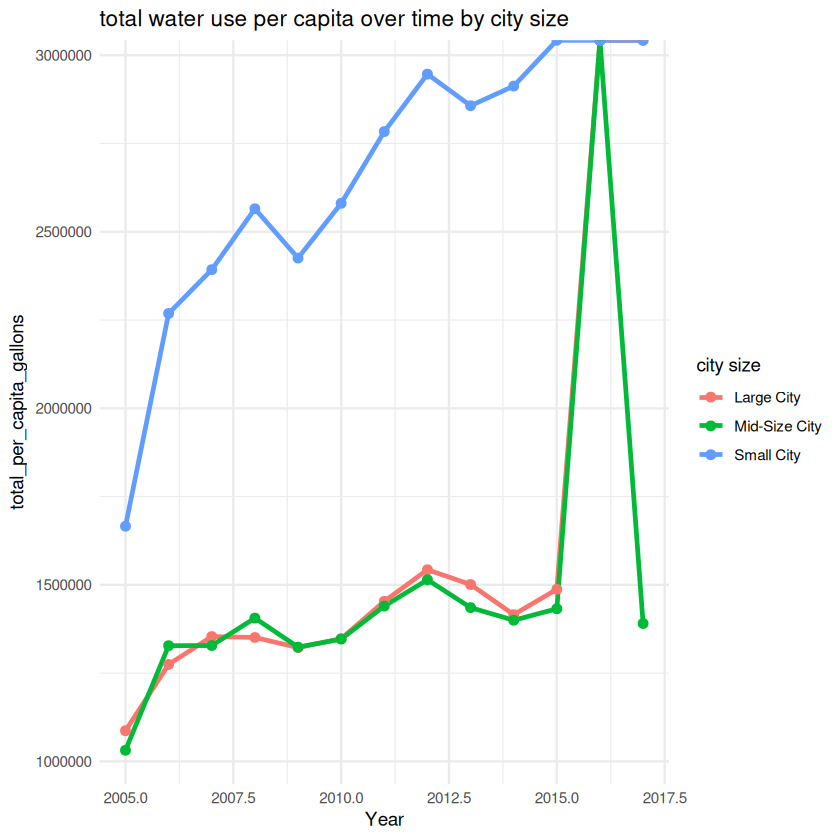

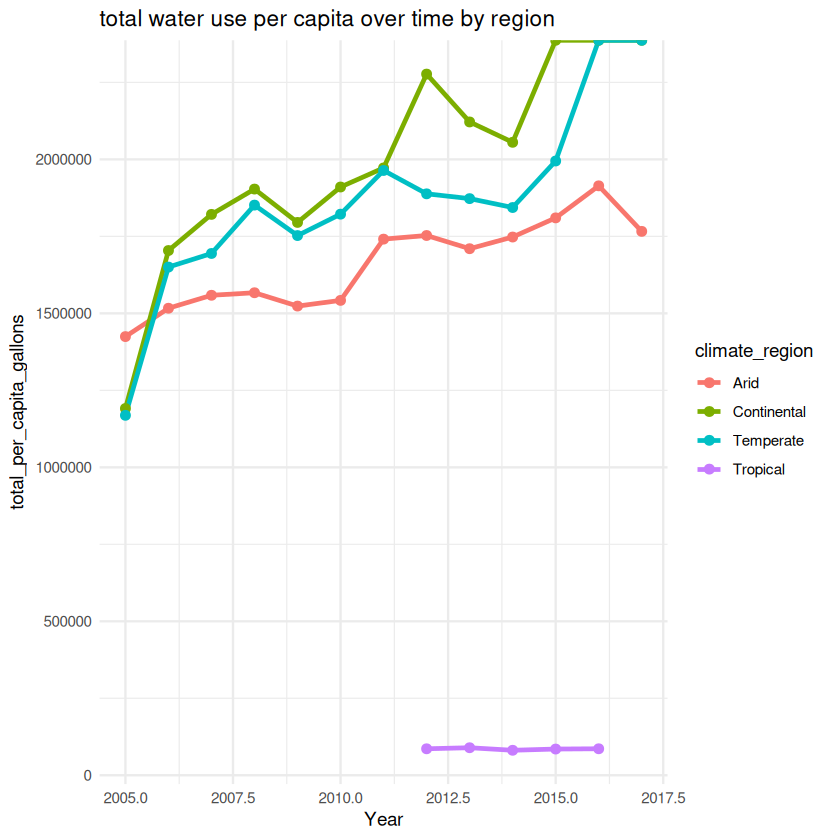

[1] 126

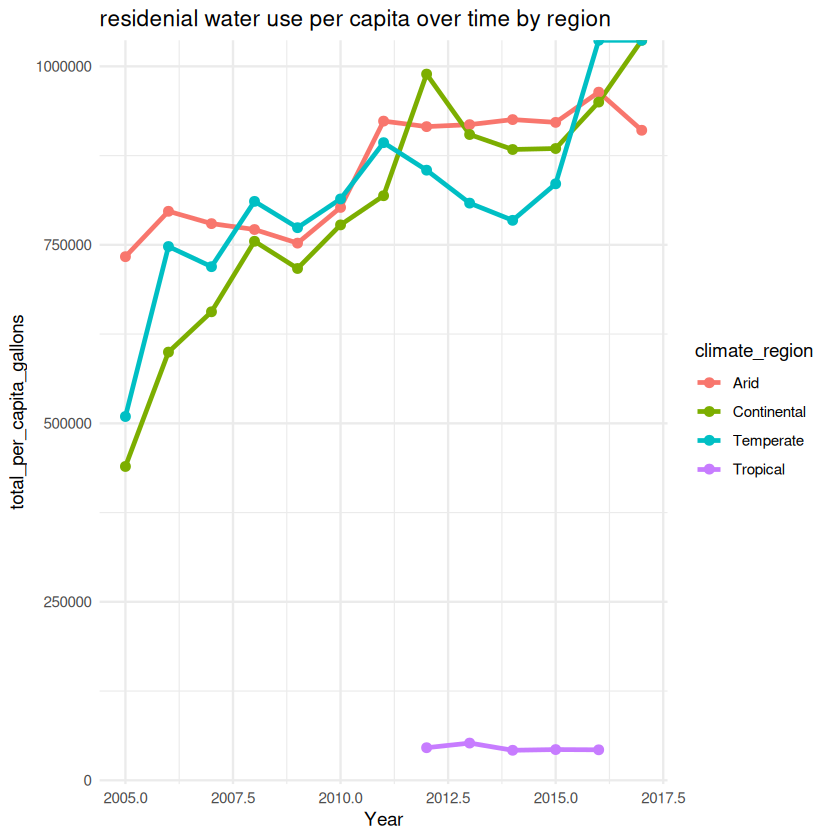

In [42]:
#summarize res_per_capita and total_per_capita by climate region and year
Muni_Water_Use_to_City_summary<-Muni_Water_Use_to_City%>%
    group_by(climate_region, year)%>%
    summarise(res_per_capita_gallons_summarise = sum(res_per_capita_gallons, na.rm = TRUE),
             total_per_capita_gallons_summarise = sum(total_per_capita_gallons, na.rm = TRUE),
             population_summarise = sum(population_summarise, na.rm = TRUE)
             )
head(Muni_Water_Use_to_City_summary)

#summarize res_per_capita and total_per_capita by city size and year
Muni_Water_Use_to_City_summary_city<-Muni_Water_Use_to_City%>%
    group_by(city_size, year)%>%
    summarise(res_per_capita_gallons_summarise = sum(res_per_capita_gallons, na.rm = TRUE),
             total_per_capita_gallons_summarise = sum(total_per_capita_gallons, na.rm = TRUE),
             population_summarise = sum(population_summarise, na.rm = TRUE)
             )
head(Muni_Water_Use_to_City_summary_city)

# Plot total per capita water use and population

# Plot total water use per capita by region from city characteristics dataset
ggplot(Muni_Water_Use_to_City_summary_city, aes(x = year, y = total_per_capita_gallons_summarise, color = city_size)) +
    geom_line (linewidth = 1) +
    geom_point(size = 2) +
         labs(
        title = "total water use per capita over time by city size",
        x = "Year",
        y = "total_per_capita_gallons",
        color = "city size"
    ) +
    theme_minimal()



# Plot total water use per capita by region from city characteristics dataset
ggplot(Muni_Water_Use_to_City_summary, aes(x = year, y = total_per_capita_gallons_summarise, color = climate_region)) +
    geom_line (linewidth = 1) +
    geom_point(size = 2) +
         labs(
        title = "total water use per capita over time by region",
        x = "Year",
        y = "total_per_capita_gallons",
        color = "climate_region"
    ) +
    theme_minimal()

# Plot residential water use per capita by region from city characteristics dataset
ggplot(Muni_Water_Use_to_City_summary, aes(x = year, y = res_per_capita_gallons_summarise, color = climate_region)) +
    geom_line (linewidth = 1) +
    geom_point(size = 2) +
         labs(
        title = "residenial water use per capita over time by region",
        x = "Year",
        y = "total_per_capita_gallons",
        color = "climate_region"
    ) +
    theme_minimal()

n_distinct(Municipal_Water_Uses_clean$city)

#needs further digging on dataframe setup, change to line and normalize


In [17]:
#bring in city characteristics shapefile for mapping

#change directory
setwd("/home/user/EDScapstone/raw_data/Cities shapefile")
my_city_shapefile <- getwd()

#see files in directory
city_shapefile_files <- list.files(my_city_shapefile)
city_shapefile_files

[1] "MunicipalWaterUseCharacterizationCities.cpg"    
[2] "MunicipalWaterUseCharacterizationCities.dbf"    
[3] "MunicipalWaterUseCharacterizationCities.prj"    
[4] "MunicipalWaterUseCharacterizationCities.sbn"    
[5] "MunicipalWaterUseCharacterizationCities.sbx"    
[6] "MunicipalWaterUseCharacterizationCities.shp"    
[7] "MunicipalWaterUseCharacterizationCities.shp.xml"
[8] "MunicipalWaterUseCharacterizationCities.shx"

In [18]:
#read in city characteristics shapefile
city_characteristics_shapefile <- st_read("/home/user/EDScapstone/raw_data/Cities shapefile/MunicipalWaterUseCharacterizationCities.shp")

str(city_characteristics_shapefile)

Reading layer `MunicipalWaterUseCharacterizationCities' from data source 
  `/home/user/EDScapstone/raw_data/Cities shapefile/MunicipalWaterUseCharacterizationCities.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 126 features and 4 fields
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: -122.71 ymin: 25.76 xmax: -68.79 ymax: 48.59
Geodetic CRS:  NAD83


Classes ‘sf’ and 'data.frame':	126 obs. of  5 variables:
 $ USCensusID: chr  "1600000US4801000" "1600000US4500550" "1600000US3501780" "1600000US3502000" ...
 $ City      : chr  "Abilene city, Texas" "Aiken city, South Carolina" "Alamogordo city, New Mexico" "Albuquerque city, New Mexico" ...
 $ latitude  : num  32.5 33.5 32.9 35.1 40.5 ...
 $ longitude : num  -99.7 -81.7 -106 -106.7 -78.4 ...
 $ geometry  :sfc_POINT of length 126; first list element:  'XY' num  -99.7 32.5
 - attr(*, "sf_column")= chr "geometry"
 - attr(*, "agr")= Factor w/ 3 levels "constant","aggregate",..: NA NA NA NA
  ..- attr(*, "names")= chr [1:4] "USCensusID" "City" "latitude" "longitude"


In [19]:
#bring in US shapefile with states

#change directory
setwd("/home/user/EDScapstone/raw_data/cb_2018_us_state_20m")
my_states_shapefile <- getwd()

list.files(my_states_shapefile)

#read in city characteristics shapefile
US_shapefile <- st_read("/home/user/EDScapstone/raw_data/cb_2018_us_state_20m/cb_2018_us_state_20m.shp")

str(US_shapefile)

unique(US_shapefile$NAME)

[1] "cb_2018_us_state_20m.cpg"            "cb_2018_us_state_20m.dbf"           
[3] "cb_2018_us_state_20m.prj"            "cb_2018_us_state_20m.shp"           
[5] "cb_2018_us_state_20m.shp.ea.iso.xml" "cb_2018_us_state_20m.shp.iso.xml"   
[7] "cb_2018_us_state_20m.shx"

Reading layer `cb_2018_us_state_20m' from data source 
  `/home/user/EDScapstone/raw_data/cb_2018_us_state_20m/cb_2018_us_state_20m.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 52 features and 9 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -179.1743 ymin: 17.91377 xmax: 179.7739 ymax: 71.35256
Geodetic CRS:  NAD83


Classes ‘sf’ and 'data.frame':	52 obs. of  10 variables:
 $ STATEFP : chr  "24" "19" "10" "39" ...
 $ STATENS : chr  "01714934" "01779785" "01779781" "01085497" ...
 $ AFFGEOID: chr  "0400000US24" "0400000US19" "0400000US10" "0400000US39" ...
 $ GEOID   : chr  "24" "19" "10" "39" ...
 $ STUSPS  : chr  "MD" "IA" "DE" "OH" ...
 $ NAME    : chr  "Maryland" "Iowa" "Delaware" "Ohio" ...
 $ LSAD    : chr  "00" "00" "00" "00" ...
 $ ALAND   : num  2.52e+10 1.45e+11 5.05e+09 1.06e+11 1.16e+11 ...
 $ AWATER  : num  6.98e+09 1.08e+09 1.40e+09 1.03e+10 3.39e+09 ...
 $ geometry:sfc_MULTIPOLYGON of length 52; first list element: List of 2
  ..$ :List of 1
  .. ..$ : num [1:6, 1:2] -76 -76 -76 -76 -76 ...
  ..$ :List of 1
  .. ..$ : num [1:261, 1:2] -79.5 -79.5 -79.5 -79.4 -79 ...
  ..- attr(*, "class")= chr [1:3] "XY" "MULTIPOLYGON" "sfg"
 - attr(*, "sf_column")= chr "geometry"
 - attr(*, "agr")= Factor w/ 3 levels "constant","aggregate",..: NA NA NA NA NA NA NA NA NA
  ..- attr(*, "names")= chr [1

[1] "Maryland"             "Iowa"                 "Delaware"            
 [4] "Ohio"                 "Pennsylvania"         "Nebraska"            
 [7] "Washington"           "Puerto Rico"          "Alabama"             
[10] "Arkansas"             "New Mexico"           "Texas"               
[13] "California"           "Kentucky"             "Georgia"             
[16] "Wisconsin"            "Oregon"               "Missouri"            
[19] "Virginia"             "Tennessee"            "Louisiana"           
[22] "New York"             "Michigan"             "Idaho"               
[25] "Florida"              "Alaska"               "Illinois"            
[28] "Montana"              "Minnesota"            "Indiana"             
[31] "Massachusetts"        "Kansas"               "Nevada"              
[34] "Vermont"              "Connecticut"          "New Jersey"          
[37] "District of Columbia" "North Carolina"       "Utah"                
[40] "North Dakota"         "South Carolina"       "Mississippi"         
[43] "Colorado"             "South Dakota"         "Oklahoma"            
[46] "Wyoming"              "West Virginia"        "Maine"               
[49] "Hawaii"               "New Hampshire"        "Arizona"             
[52] "Rhode Island"

In [20]:
#filter US shapefile to contiguous US states where the municipal dataset is
US_shapefile_contiguous <- US_shapefile%>%
    filter (!NAME %in% c("Alaska", "Hawaii", "Puerto Rico")
       )

#check it worked
unique(US_shapefile_contiguous$NAME)

[1] "Maryland"             "Iowa"                 "Delaware"            
 [4] "Ohio"                 "Pennsylvania"         "Nebraska"            
 [7] "Washington"           "Alabama"              "Arkansas"            
[10] "New Mexico"           "Texas"                "California"          
[13] "Kentucky"             "Georgia"              "Wisconsin"           
[16] "Oregon"               "Missouri"             "Virginia"            
[19] "Tennessee"            "Louisiana"            "New York"            
[22] "Michigan"             "Idaho"                "Florida"             
[25] "Illinois"             "Montana"              "Minnesota"           
[28] "Indiana"              "Massachusetts"        "Kansas"              
[31] "Nevada"               "Vermont"              "Connecticut"         
[34] "New Jersey"           "District of Columbia" "North Carolina"      
[37] "Utah"                 "North Dakota"         "South Carolina"      
[40] "Mississippi"          "Colorado"             "South Dakota"        
[43] "Oklahoma"             "Wyoming"              "West Virginia"       
[46] "Maine"                "New Hampshire"        "Arizona"             
[49] "Rhode Island"

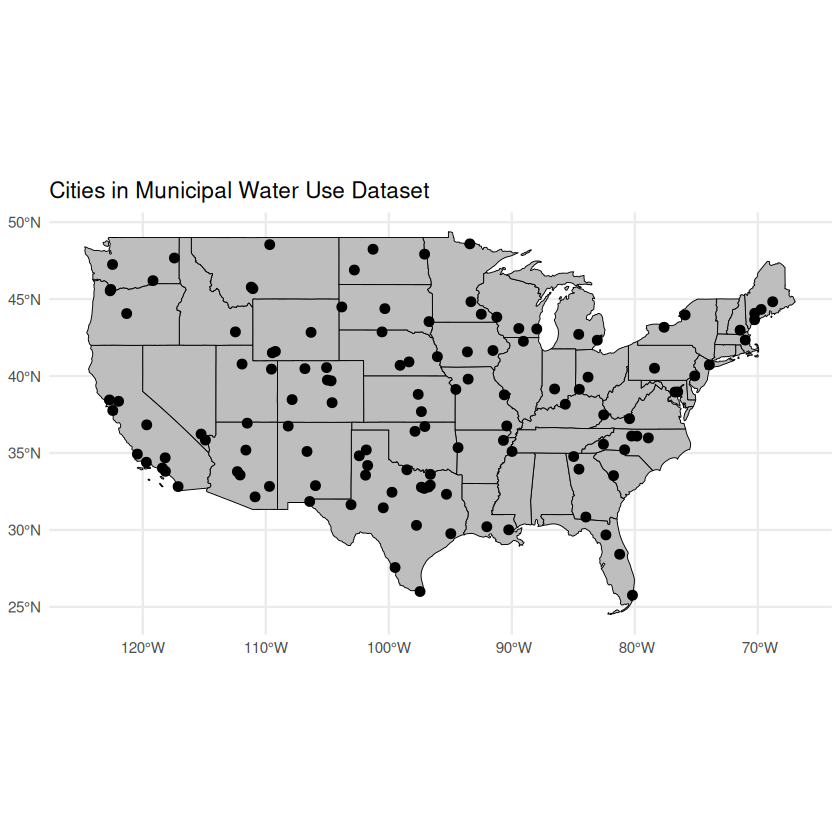

In [21]:
#plot city characteristics shapefile
ggplot()+
    geom_sf(data= US_shapefile_contiguous, color = "black", fill = "gray")+ 
    geom_sf(data = city_characteristics_shapefile, fill= "white", size = 2)+
    labs(title = "Cities in Municipal Water Use Dataset") +
    theme_minimal() 

#make sure coordinate system is the same when bringing in shapefiles-- is NAD84 CRS sufficient of a check? bounding box?

#size of points by pop size binning?
#color of dots for rural-urban divide?
#color of dot by increasing-decreasing-stable pop?


In [22]:
#bring in Census urban areas

#change directory
setwd("/home/user/EDScapstone/raw_data/")
list.files()
setwd("/home/user/EDScapstone/raw_data/cb_2018_us_ua10_500k/")
my_urban_shapefile <- getwd()
list.files()

#read in urban shapefile
urban_shapefile <- st_read("/home/user/EDScapstone/raw_data/cb_2018_us_ua10_500k/cb_2018_us_ua10_500k.shp")

str(urban_shapefile)

[1] "cb_2018_us_state_20m"                      
 [2] "cb_2018_us_ua10_500k"                      
 [3] "Cities shapefile"                          
 [4] "Cities shapefile.zip"                      
 [5] "City-characteristics.csv"                  
 [6] "Municipal_water_uses_dataset_2005-2017.csv"
 [7] "old"                                       
 [8] "readme.md"                                 
 [9] "tl_2020_us_uac20"                          
[10] "tl_2020_us_uac20.zip"

[1] "cb_2018_us_ua10_500k.cpg"            "cb_2018_us_ua10_500k.dbf"           
[3] "cb_2018_us_ua10_500k.prj"            "cb_2018_us_ua10_500k.shp"           
[5] "cb_2018_us_ua10_500k.shp.ea.iso.xml" "cb_2018_us_ua10_500k.shp.iso.xml"   
[7] "cb_2018_us_ua10_500k.shx"

Reading layer `cb_2018_us_ua10_500k' from data source 
  `/home/user/EDScapstone/raw_data/cb_2018_us_ua10_500k/cb_2018_us_ua10_500k.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 3601 features and 8 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -170.7894 ymin: -14.37374 xmax: 145.7909 ymax: 71.30684
Geodetic CRS:  NAD83


Classes ‘sf’ and 'data.frame':	3601 obs. of  9 variables:
 $ UACE10    : chr  "88732" "01819" "22366" "93322" ...
 $ AFFGEOID10: chr  "400C100US88732" "400C100US01819" "400C100US22366" "400C100US93322" ...
 $ GEOID10   : chr  "88732" "01819" "22366" "93322" ...
 $ NAME10    : chr  "Tucson, AZ" "Alturas, CA" "Davenport, IA--IL" "Waynesboro, PA--MD" ...
 $ LSAD10    : chr  "75" "76" "75" "76" ...
 $ UATYP10   : chr  "U" "C" "U" "C" ...
 $ ALAND10   : num  9.15e+08 4.93e+06 3.57e+08 4.55e+07 2.36e+07 ...
 $ AWATER10  : num  2078695 16517 21444164 88872 3913803 ...
 $ geometry  :sfc_MULTIPOLYGON of length 3601; first list element: List of 11
  ..$ :List of 1
  .. ..$ : num [1:28, 1:2] -111 -111 -111 -111 -111 ...
  ..$ :List of 1
  .. ..$ : num [1:68, 1:2] -111 -111 -111 -111 -111 ...
  ..$ :List of 1
  .. ..$ : num [1:8, 1:2] -111 -111 -111 -111 -111 ...
  ..$ :List of 1
  .. ..$ : num [1:6, 1:2] -111 -111 -111 -111 -111 ...
  ..$ :List of 1
  .. ..$ : num [1:8, 1:2] -111 -111 -111 -111 -

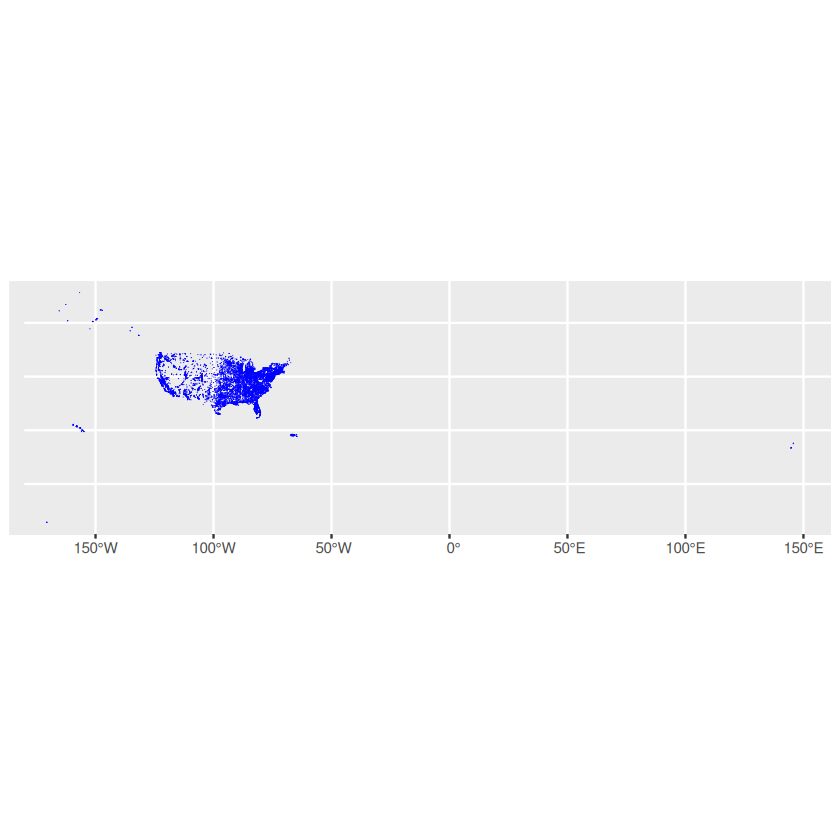

In [23]:
#plot 
ggplot()+
    geom_sf(data= urban_shapefile, color = "blue", fill = "gray")

# geographic extent does not match the Municipal Water Use Dataset extent

In [24]:
# select urban areas that intersect the contiguous US shapefile

#verify same CRS-- both are NAD83
    select_urban <- st_intersects(urban_shapefile, US_shapefile_contiguous, sparse = FALSE)
    selected_urban_areas <- urban_shapefile[apply(select_urban, 1, any), ]

# intersection
    print(selected_urban_areas)

Simple feature collection with 3535 features and 8 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -124.4378 ymin: 24.54451 xmax: -67.23016 ymax: 49.00236
Geodetic CRS:  NAD83
First 10 features:
   UACE10     AFFGEOID10 GEOID10                           NAME10 LSAD10
1   88732 400C100US88732   88732                       Tucson, AZ     75
2   01819 400C100US01819   01819                      Alturas, CA     76
3   22366 400C100US22366   22366                Davenport, IA--IL     75
4   93322 400C100US93322   93322               Waynesboro, PA--MD     76
5   02548 400C100US02548   02548                       Angola, IN     76
6   10891 400C100US10891   10891       Browns Mills--Fort Dix, NJ     76
7   15508 400C100US15508   15508 Charleston--North Charleston, SC     75
8   13375 400C100US13375   13375                       Canton, OH     75
9   97291 400C100US97291   97291                Worcester, MA--CT     75
10  56170 400C100US56170   56170                 

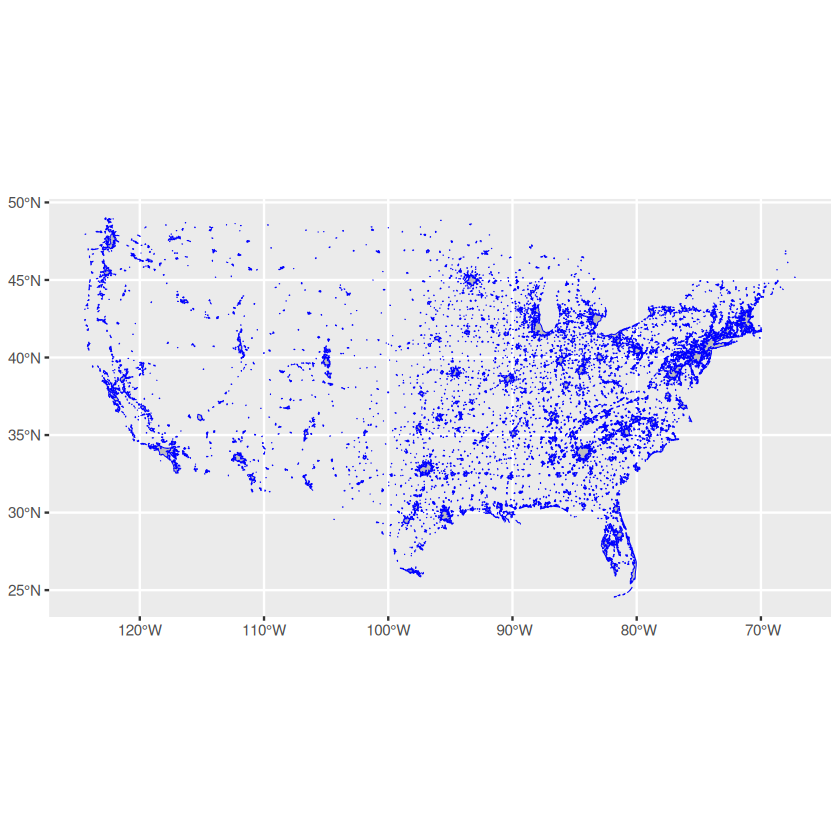

In [25]:
#plot 
ggplot()+
    geom_sf(data= selected_urban_areas, color = "blue", fill = "gray")

#now only shows data in contiguous US

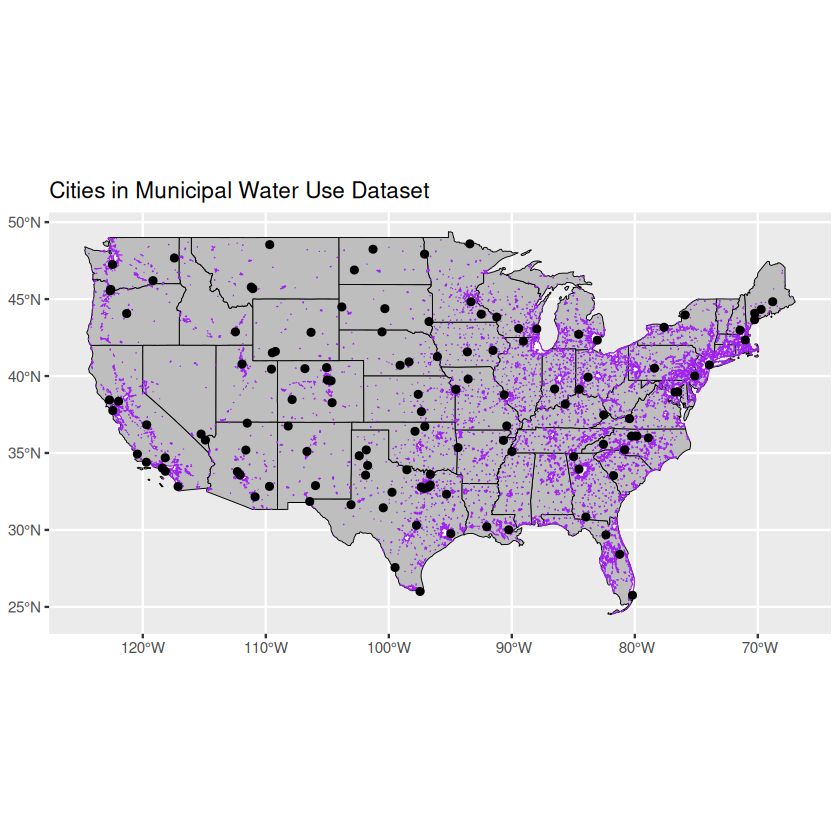

In [26]:
#plot city characteristics shapefile
ggplot()+
    geom_sf(data= US_shapefile_contiguous, color = "black", fill = "gray")+ 
    geom_sf(data= selected_urban_areas, color = "purple", fill = "white") +
    geom_sf(data = city_characteristics_shapefile) +
    labs(title = "Cities in Municipal Water Use Dataset") 
# add legend
 

In [27]:
#temporarily filter dataset to look at one record
print(selected_urban_areas%>%
    filter (NAME10 == "Tucson, AZ"))
       
#how to zoom into one record?

Simple feature collection with 1 feature and 8 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -111.1837 ymin: 32.03455 xmax: -110.7209 ymax: 32.55454
Geodetic CRS:  NAD83
  UACE10     AFFGEOID10 GEOID10     NAME10 LSAD10 UATYP10   ALAND10 AWATER10
1  88732 400C100US88732   88732 Tucson, AZ     75       U 915276150  2078695
                        geometry
1 MULTIPOLYGON (((-110.8135 3...


Simple feature collection with 115 features and 4 fields
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: -122.71 ymin: 25.76 xmax: -68.79 ymax: 48.59
Geodetic CRS:  NAD83
First 10 features:
         USCensusID                           City latitude longitude
1  1600000US4801000            Abilene city, Texas    32.45    -99.74
2  1600000US4500550     Aiken city, South Carolina    33.53    -81.73
3  1600000US3501780    Alamogordo city, New Mexico    32.88   -105.96
4  1600000US3502000   Albuquerque city, New Mexico    35.10   -106.65
5  1600000US4202184     Altoona city, Pennsylvania    40.51    -78.40
6  1600000US4803000           Amarillo city, Texas    35.20   -101.83
7  1600000US2401600       Annapolis city, Maryland    38.97    -76.51
8  1600000US4804000          Arlington city, Texas    32.70    -97.12
9  1600000US3702140 Asheville city, North Carolina    35.57    -82.55
10 1600000US2302060             Auburn city, Maine    44.08    -70.25
                geometry
1  

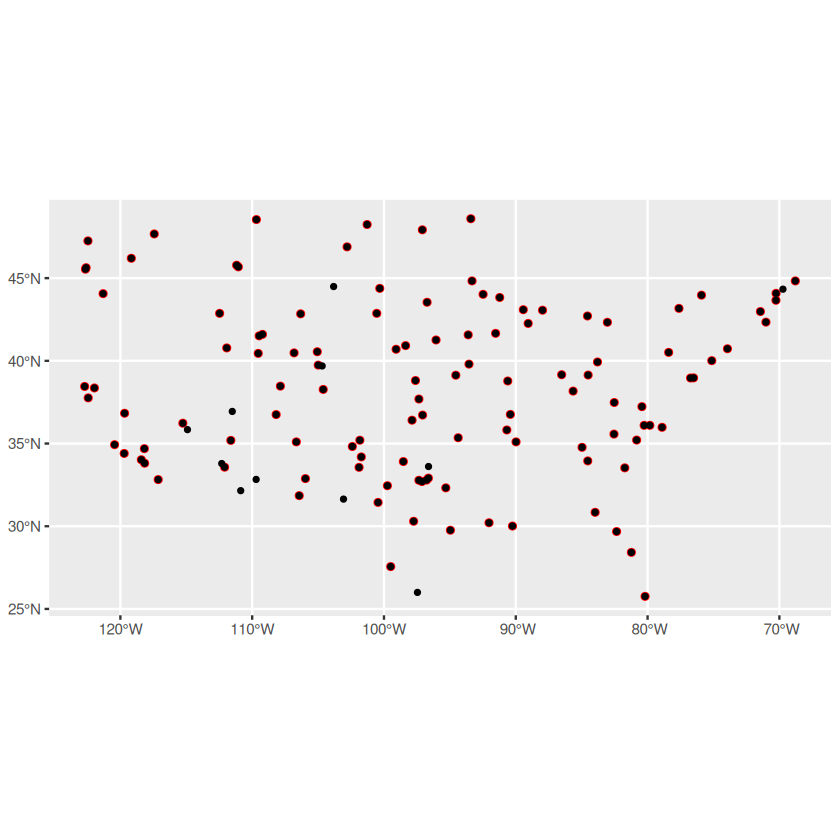

In [28]:
#which cities are in urban areas? are the cities in urban areas by definition?

# select cities that intersect the filtered urban areas

#verify same CRS-- both are NAD83
    select_urban_cities <- st_intersects(city_characteristics_shapefile, selected_urban_areas, sparse = FALSE)
    selected_urban_cities <- city_characteristics_shapefile[apply(select_urban_cities, 1, any), ]

# print intersection
    print(selected_urban_cities)

#plot cities intersection 
ggplot()+
    geom_sf(data= selected_urban_cities, fill = "blue", color = "red") +
    geom_sf(data = city_characteristics_shapefile, fill= "white", size = 1)


#maybe remove cities in analysis that are not part of urban areas?